In [1]:
import torch
import gpytorch
import pandas as pd
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from torch.utils.data import TensorDataset, DataLoader
from pyproj import Transformer
from sklearn.metrics import pairwise_distances
from scipy.interpolate import RegularGridInterpolator
from torch_geometric.data import Data




/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:

with open("analysis_dataset_enriched.p", "rb") as f:
  df_processed_enriched = pickle.load(f)

In [3]:
df_processed_enriched['sensor_index'].nunique()

43

In [4]:
expected_counts = df_processed_enriched.groupby('sensor_index').apply(
    lambda g: (g['date'].max() - g['date'].min()).days + 1
)
actual_counts = df_processed_enriched.groupby('sensor_index')['date'].count()

missing_report = pd.DataFrame(
    {'expected': expected_counts, 'actual': actual_counts}
)
missing_report['missing_days'] = (
    missing_report['expected'] - missing_report['actual']
)
print(missing_report[missing_report['missing_days'] > 0])

Empty DataFrame
Columns: [expected, actual, missing_days]
Index: []


In [ ]:
#now connect the sensors into a air monitoring network. 

In [7]:
df_processed_enriched.columns

Index(['sensor_index', 'date', 'pm25_epa_corrected', 'latitude', 'longitude',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'relative_humidity_2m_mean', 'precipitation_sum', 'windgusts_10m_max',
       'surface_pressure_mean', 'et0_fao_evapotranspiration',
       'windspeed_10m_mean', 'winddirection_10m_prevailing',
       'major_roads_count_3km', 'urban_landuse_area_m2_3km',
       'building_footprint_area_3km', 'green_space_area_3km',
       'total_road_length_3km', 'railway_length_3km', 'elevation_m'],
      dtype='str')

In [5]:
df_processed_enriched.head(5)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,...,et0_fao_evapotranspiration,windspeed_10m_mean,winddirection_10m_prevailing,major_roads_count_3km,urban_landuse_area_m2_3km,building_footprint_area_3km,green_space_area_3km,total_road_length_3km,railway_length_3km,elevation_m
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,...,4.73,5.919843,4.877802,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
1,5330,2021-06-26,20.636,36.80372,126.93623,26.0,20.4,22.2,82,4.1,...,3.28,2.412766,50.944546,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
2,5330,2021-05-19,29.206,36.80372,126.93623,25.0,10.2,17.9,69,0.0,...,4.93,2.605699,342.812818,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
3,5330,2021-06-25,21.796,36.80372,126.93623,27.3,17.9,22.4,78,0.2,...,4.31,2.412209,254.489263,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0
4,5330,2021-04-17,9.432,36.80372,126.93623,13.4,5.3,8.8,63,0.2,...,2.90,8.958965,271.374110,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0


In [25]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

# 1. Pivot data to align time-series per sensor
pivot_df = df_processed_enriched.pivot(
    index="date", columns="sensor_index", values="pm25_epa_corrected"
)

# 2. Extract unique sensor coordinates matching the pivot columns
sensor_coords = (
    df_processed_enriched[["sensor_index", "latitude", "longitude"]]
    .drop_duplicates("sensor_index")
    .set_index("sensor_index")
    .reindex(pivot_df.columns)
)

# 3. Compute Geographic Distance Matrix (Haversine formula in km)
coords_rad = np.radians(sensor_coords[["latitude", "longitude"]].values)


def compute_haversine_matrix(coords):
  lat1, lon1 = coords[:, 0], coords[:, 1]
  dlat = lat1[:, np.newaxis] - lat1
  dlon = lon1[:, np.newaxis] - lon1
  a = (
      np.sin(dlat / 2.0) ** 2
      + np.cos(lat1[:, np.newaxis]) * np.cos(lat1) * np.sin(dlon / 2.0) ** 2
  )
  c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
  return c * 6371.0  # Earth radius in km


geo_dist_matrix = compute_haversine_matrix(coords_rad)

# 4. Compute Temporal Dissimilarity Matrix (1 - Pearson Correlation)
corr_matrix = pivot_df.corr(method="pearson").values
corr_matrix = np.nan_to_num(
    corr_matrix, nan=0.0
)  # Handle any missing overlaps safely
temp_dist_matrix = 1.0 - corr_matrix  # Higher correlation = lower dissimilarity

# 5. Extract lower triangles for matrix comparison
n_sensors = geo_dist_matrix.shape[0]
i_lower = np.tril_indices(n_sensors, k=-1)
x = geo_dist_matrix[i_lower]
y = temp_dist_matrix[i_lower]

# Filter out invalid entries
valid = ~np.isnan(x) & ~np.isnan(y)
x, y = x[valid], y[valid]

# 6. Execute Mantel Permutation Test
observed_r, _ = pearsonr(x, y)


def run_mantel_test(geo_sq, temp_sq, observed_r, permutations=999, seed=42):
  n = geo_sq.shape[0]
  i_tril = np.tril_indices(n, k=-1)
  x_flat = geo_sq[i_tril]

  count = 0
  rng = np.default_rng(seed) if hasattr(np, "default_rng") else np.random.default_rng(seed)

  for _ in range(permutations):
    perm_idx = rng.permutation(n)
    # Permute rows and columns of the dissimilarity matrix identically
    temp_perm = temp_sq[perm_idx][:, perm_idx]
    y_perm = temp_perm[i_tril]

    r, _ = pearsonr(x_flat, y_perm)
    if abs(r) >= abs(observed_r):
      count += 1

  p_value = (count + 1) / (permutations + 1)
  return observed_r, p_value


mantel_r, p_value = run_mantel_test(
    geo_dist_matrix, temp_dist_matrix, observed_r, permutations=9999
)

print(f"Mantel r (Matrix Correlation): {mantel_r:.4f}")
print(f"Permutation p-value: {p_value:.4f}")

Mantel r (Matrix Correlation): 0.3410
Permutation p-value: 0.0498


In [26]:
#do the testing by season to examine interseason spatial correlation. 


# 1. Map dates to meteorological seasons
def get_season(month):
  if month in [3, 4, 5]:
    return "Spring"
  elif month in [6, 7, 8]:
    return "Summer"
  elif month in [9, 10, 11]:
    return "Autumn"
  else:
    return "Winter"


df_processed_enriched["date"] = pd.to_datetime(df_processed_enriched["date"])
df_processed_enriched["season"] = df_processed_enriched["date"].dt.month.apply(
    get_season
)


# 2. Helper functions for Haversine distance and Mantel test
def compute_haversine_matrix(coords):
  lat1, lon1 = np.radians(coords[:, 0]), np.radians(coords[:, 1])
  dlat = lat1[:, np.newaxis] - lat1
  dlon = lon1[:, np.newaxis] - lon1
  a = (
      np.sin(dlat / 2.0) ** 2
      + np.cos(lat1[:, np.newaxis]) * np.cos(lat1) * np.sin(dlon / 2.0) ** 2
  )
  c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
  return c * 6371.0


def run_mantel_test(geo_sq, temp_sq, observed_r, permutations=999, seed=42):
  n = geo_sq.shape[0]
  i_tril = np.tril_indices(n, k=-1)
  x_flat = geo_sq[i_tril]
  count = 0
  # FIXED: Use np.random.default_rng instead of np.default_rng
  rng = np.random.default_rng(seed)

  for _ in range(permutations):
    perm_idx = rng.permutation(n)
    temp_perm = temp_sq[perm_idx][:, perm_idx]
    y_perm = temp_perm[i_tril]
    r, _ = pearsonr(x_flat, y_perm)
    if abs(r) >= abs(observed_r):
      count += 1
  return (count + 1) / (permutations + 1)


# 3. Iterate through each season and run the analysis
seasonal_results = []

for season, group_df in df_processed_enriched.groupby("season"):
  pivot_df = group_df.pivot(
      index="date", columns="sensor_index", values="pm25_epa_corrected"
  )

  sensor_coords = (
      group_df[["sensor_index", "latitude", "longitude"]]
      .drop_duplicates("sensor_index")
      .set_index("sensor_index")
      .reindex(pivot_df.columns)
  )

  # Clean columns with missing coordinates or all NaNs
  valid_cols = ~sensor_coords.isnull().any(axis=1) & ~pivot_df.isnull().all(
      axis=0
  )
  pivot_df = pivot_df.loc[:, valid_cols]
  sensor_coords = sensor_coords.loc[valid_cols]

  if pivot_df.shape[1] < 3:
    continue

  # Build distance matrices
  coords_arr = sensor_coords[["latitude", "longitude"]].values
  geo_dist = compute_haversine_matrix(coords_arr)

  corr_matrix = pivot_df.corr(method="pearson").values
  corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)
  temp_dist = 1.0 - corr_matrix

  i_lower = np.tril_indices(geo_dist.shape[0], k=-1)
  x = geo_dist[i_lower]
  y = temp_dist[i_lower]
  valid = ~np.isnan(x) & ~np.isnan(y)

  if valid.sum() < 3:
    continue

  observed_r, _ = pearsonr(x[valid], y[valid])
  p_value = run_mantel_test(geo_dist, temp_dist, observed_r, permutations=999)

  seasonal_results.append({
      "season": season,
      "mantel_r": observed_r,
      "p_value": p_value,
  })

# 4. Output summary table
results_df = pd.DataFrame(seasonal_results)
print(results_df.to_string(index=False))

season  mantel_r  p_value
Autumn  0.448067    0.016
Spring  0.365512    0.014
Summer  0.314237    0.053
Winter  0.357596    0.042


In [27]:
df_processed_enriched.head(10)

,sensor_index,date,pm25_epa_corrected,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum,...,windspeed_10m_mean,winddirection_10m_prevailing,major_roads_count_3km,urban_landuse_area_m2_3km,building_footprint_area_3km,green_space_area_3km,total_road_length_3km,railway_length_3km,elevation_m,season
0,5330,2021-06-12,30.116,36.80372,126.93623,28.7,17.7,21.9,83,0.0,...,5.919843,4.877802,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Summer
1,5330,2021-06-26,20.636,36.80372,126.93623,26.0,20.4,22.2,82,4.1,...,2.412766,50.944546,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Summer
2,5330,2021-05-19,29.206,36.80372,126.93623,25.0,10.2,17.9,69,0.0,...,2.605699,342.812818,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Spring
3,5330,2021-06-25,21.796,36.80372,126.93623,27.3,17.9,22.4,78,0.2,...,2.412209,254.489263,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Summer
4,5330,2021-04-17,9.432,36.80372,126.93623,13.4,5.3,8.8,63,0.2,...,8.958965,271.374110,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Spring
5,5330,2021-05-31,15.832,36.80372,126.93623,24.3,16.2,19.4,74,6.1,...,7.765720,207.660283,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Spring
6,5330,2021-06-03,14.542,36.80372,126.93623,22.8,16.8,19.3,86,20.3,...,1.433398,163.936642,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Summer
7,5330,2021-05-02,13.646,36.80372,126.93623,16.6,7.8,11.2,71,2.1,...,9.783779,316.248067,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Spring
8,5330,2021-04-06,38.808,36.80372,126.93623,17.4,5.6,11.0,58,0.0,...,5.808721,294.606572,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Spring
9,5330,2021-04-08,15.874,36.80372,126.93623,16.0,3.8,10.1,58,0.0,...,8.888522,301.978443,58.0,734199.902239,119829.332792,3.927114e+06,241695.110508,0.0,24.0,Spring


[Autumn] n_days=156 n_pairs= 903 pooled_var= 122.7 nugget=  69.8 sill= 294.4 range_param= 170.1km eff_range= 510.3km practical_range=  76.1km -> chosen=  76.1km [parametric fit unreliable here]
[Spring] n_days=153 n_pairs= 903 pooled_var=  46.1 nugget=  27.5 sill=  49.5 range_param=  56.0km eff_range= 167.9km practical_range=  13.9km -> chosen=  13.9km
[Summer] n_days=184 n_pairs= 903 pooled_var= 126.5 nugget= 129.5 sill=   0.0 range_param=  22.0km eff_range=  65.9km practical_range=  10.9km -> chosen=  10.9km [parametric fit unreliable here]
[Winter] n_days= 90 n_pairs= 903 pooled_var=  37.4 nugget=  22.3 sill=  44.2 range_param=  66.4km eff_range= 199.1km practical_range=  41.9km -> chosen=  41.9km [parametric fit unreliable here]

Final seasonal cutoffs (km): {'Autumn': np.float64(76.1), 'Spring': np.float64(13.9), 'Summer': np.float64(10.9), 'Winter': np.float64(41.9)}


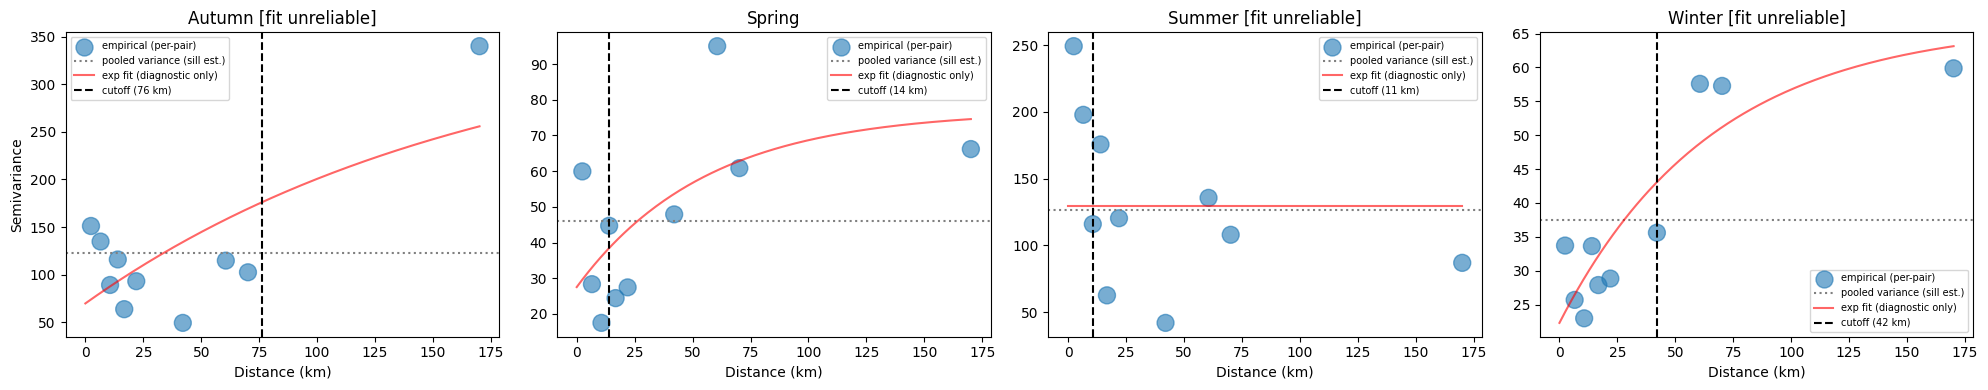

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics.pairwise import haversine_distances

def get_season(month):
  if month in [3, 4, 5]:
    return "Spring"
  elif month in [6, 7, 8]:
    return "Summer"
  elif month in [9, 10, 11]:
    return "Autumn"
  else:
    return "Winter"

if "season" not in df_processed_enriched.columns:
  df_processed_enriched["season"] = pd.to_datetime(
      df_processed_enriched["date"]
  ).dt.month.apply(get_season)

daily_mean = df_processed_enriched.groupby("date")["pm25_epa_corrected"].transform("mean")
df_processed_enriched["pm25_epa_corrected_anomaly"] = (
    df_processed_enriched["pm25_epa_corrected"] - daily_mean
)


def exponential_variogram(h, nugget, sill, rng):
  return nugget + sill * (1 - np.exp(-h / rng))


def pairwise_semivariogram(df_season, value_col, n_bins=10, min_pairs_per_bin=20):
  """One (distance, mean squared difference) point per UNIQUE sensor pair,
  averaged over all days both sensors reported -- not per (day, pair) row.
  A sensor pair's distance is fixed, so pooling raw (day, pair) rows treats
  ~150 repeated daily observations of the same physical pair as independent
  spatial samples (pseudo-replication) and gives the downstream fit false
  confidence. Aggregating over time first gives one honest spatial degree of
  freedom per geographic pair."""
  pivot = df_season.pivot(index="date", columns="sensor_index", values=value_col)
  sensors = pivot.columns.tolist()
  n = len(sensors)

  meta = (
      df_season[["sensor_index", "latitude", "longitude"]]
      .drop_duplicates("sensor_index").set_index("sensor_index").reindex(sensors)
  )
  dist = haversine_distances(np.radians(meta[["latitude", "longitude"]].values)) * 6371.0

  vals = pivot.values
  sqdiff_sum = np.zeros((n, n))
  sqdiff_cnt = np.zeros((n, n))
  for row in vals:
    idx = np.where(~np.isnan(row))[0]
    sub = row[idx]
    d2 = (sub[:, None] - sub[None, :]) ** 2
    sqdiff_sum[np.ix_(idx, idx)] += d2
    sqdiff_cnt[np.ix_(idx, idx)] += 1

  iu = np.triu_indices(n, k=1)
  pair_dist, pair_sum, pair_cnt = dist[iu], sqdiff_sum[iu], sqdiff_cnt[iu]
  valid = pair_cnt > 10  # require at least 10 shared days to trust a pair's mean
  pair_gamma = 0.5 * pair_sum[valid] / pair_cnt[valid]
  pair_dist = pair_dist[valid]

  bin_id = pd.qcut(pair_dist, q=n_bins, duplicates="drop")
  grouped = (
      pd.DataFrame({"d": pair_dist, "gamma": pair_gamma, "bin": bin_id})
      .groupby("bin", observed=True)
      .agg(h=("d", "mean"), gamma=("gamma", "mean"), n=("d", "size"))
  )
  grouped = grouped[grouped["n"] >= min_pairs_per_bin].reset_index(drop=True)
  return grouped["h"].values, grouped["gamma"].values, grouped["n"].values


def practical_range(h, gamma, sill_est, frac=0.95):
  """Distance at which the empirical semivariogram first crosses frac*sill,
  via linear interpolation between bin centers. Bounded by construction --
  can never exceed the max distance actually observed in the data, unlike
  the parametric fit's extrapolated 3x-range-parameter 'effective range'."""
  target = frac * sill_est
  for k in range(len(h) - 1):
    if gamma[k] < target <= gamma[k + 1]:
      t = (target - gamma[k]) / (gamma[k + 1] - gamma[k])
      return h[k] + t * (h[k + 1] - h[k])
  return h[-1]


def fit_seasonal_ranges(df, value_col="pm25_epa_corrected_anomaly", n_bins=10):
  seasonal_ranges, seasonal_fits = {}, {}

  for season, season_df in df.groupby("season"):
    h, gamma, counts = pairwise_semivariogram(season_df, value_col, n_bins=n_bins)
    if len(h) < 4:
      print(f"[{season}] not enough well-sampled distance bins -- skipping")
      continue

    pooled_var = season_df[value_col].var()
    prac_range = practical_range(h, gamma, pooled_var, frac=0.95)

    lb = [0.0, 0.0, 1e-3]
    ub = [pooled_var * 2, pooled_var * 3, h.max()]
    p0 = [np.clip(gamma[0], lb[0], ub[0]), np.clip(pooled_var - gamma[0], lb[1], ub[1]), h[len(h) // 2]]
    try:
      popt, _ = curve_fit(exponential_variogram, h, gamma, p0=p0, bounds=(lb, ub),
                           sigma=1 / np.sqrt(counts), maxfev=20000)
      nugget, sill, rng = popt
      effective_range = 3 * rng
      degenerate = bool(
          np.isclose(rng, h.max(), rtol=1e-3)   # fit pinned to its upper bound
          or sill < 0.1 * pooled_var             # essentially pure nugget, no structure
          or effective_range > h.max()           # extrapolates past observed distances
      )
    except RuntimeError:
      nugget, sill, rng, effective_range, degenerate = np.nan, np.nan, np.nan, np.nan, True

    # Practical range is the primary cutoff: bounded by the observed data by
    # construction, doesn't rely on the parametric exponential shape holding.
    # The fit itself is kept only as a diagnostic (nugget/sill split, curve for the plot).
    chosen_range = prac_range

    seasonal_ranges[season] = chosen_range
    seasonal_fits[season] = dict(h=h, gamma=gamma, counts=counts, pooled_var=pooled_var,
                                  nugget=nugget, sill=sill, range_param=rng,
                                  effective_range=effective_range, practical_range=prac_range,
                                  degenerate=degenerate, chosen_range=chosen_range)

    flag = " [parametric fit unreliable here]" if degenerate else ""
    print(f"[{season}] n_days={season_df['date'].nunique():3d} n_pairs={counts.sum():4d} "
          f"pooled_var={pooled_var:6.1f} nugget={nugget:6.1f} sill={sill:6.1f} "
          f"range_param={rng:6.1f}km eff_range={effective_range:6.1f}km "
          f"practical_range={prac_range:6.1f}km -> chosen={chosen_range:6.1f}km{flag}")

  return seasonal_ranges, seasonal_fits


seasonal_ranges_km, seasonal_variogram_fits = fit_seasonal_ranges(df_processed_enriched)
print("\nFinal seasonal cutoffs (km):", {k: round(v, 1) for k, v in seasonal_ranges_km.items()})

# Diagnostic plot: empirical semivariogram + fitted curve + chosen cutoff, per season
fig, axes = plt.subplots(1, len(seasonal_variogram_fits), figsize=(5 * len(seasonal_variogram_fits), 4))
if len(seasonal_variogram_fits) == 1:
  axes = [axes]
for ax, (season, fit) in zip(axes, seasonal_variogram_fits.items()):
  ax.scatter(fit["h"], fit["gamma"], s=fit["counts"] / fit["counts"].max() * 150, alpha=0.6, label="empirical (per-pair)")
  ax.axhline(fit["pooled_var"], color="gray", linestyle=":", label="pooled variance (sill est.)")
  if not np.isnan(fit["range_param"]):
    h_fine = np.linspace(0, fit["h"].max(), 200)
    ax.plot(h_fine, exponential_variogram(h_fine, fit["nugget"], fit["sill"], fit["range_param"]), "r-", alpha=0.6, label="exp fit (diagnostic only)")
  ax.axvline(fit["chosen_range"], color="k", linestyle="--", label=f"cutoff ({fit['chosen_range']:.0f} km)")
  ax.set_title(f"{season}{' [fit unreliable]' if fit['degenerate'] else ''}")
  ax.set_xlabel("Distance (km)")
  ax.legend(fontsize=7)
axes[0].set_ylabel("Semivariance")
plt.tight_layout()
plt.show()


In [38]:
# ---------------------------------------------------------------------------
# Step 2: distance-dependent wind-direction alignment
# ---------------------------------------------------------------------------
# Below near_km, wind direction is ignored entirely -- undirected distance
# decay only, since the data showed no validated directional effect at short
# range (if anything, a small backwards tilt). Above far_km, alignment is
# fully required and gated at alignment_floor. In between, a smooth blend.

def compute_local_vectors(lat, lon):
  """East (dx) / north (dy) displacement in km from every sensor i to every
  sensor j, using a local tangent-plane approximation."""
  lat_r, lon_r, R = np.radians(lat), np.radians(lon), 6371.0
  dlat = lat_r[None, :] - lat_r[:, None]
  dlon = lon_r[None, :] - lon_r[:, None]
  mean_lat = (lat_r[:, None] + lat_r[None, :]) / 2
  dx = dlon * np.cos(mean_lat) * R
  dy = dlat * R
  return dx, dy  # dx[i, j], dy[i, j] = displacement from i to j


def wind_direction_to_vector(wind_dir_from_deg):
  """Convert a compass 'blowing FROM' direction (degrees) into a unit
  (east, north) vector pointing in the direction the wind is blowing TOWARDS."""
  wind_to_deg = (wind_dir_from_deg + 180.0) % 360.0
  theta = np.radians(wind_to_deg)
  return np.sin(theta), np.cos(theta)


def distance_alignment_weight(dist, near_km=30.0, far_km=50.0):
  """How much directional alignment should matter at distance `dist`, in
  [0, 1]. 0 below near_km (ignore wind direction -- plain distance decay),
  ramping smoothly to 1 at far_km and beyond (wind alignment fully required).
  Boundaries backed by the downwind-vs-upwind check: no validated
  directional effect under ~50km, but a real, threshold-stable effect
  beyond it."""
  w = (dist - near_km) / (far_km - near_km)
  w = np.clip(w, 0.0, 1.0)
  return w * w * (3 - 2 * w)  # smoothstep, avoids a hard kink at the boundaries


def directional_alignment(lat, lon, wind_dir_from_deg, alignment_floor=0.3,
                           near_km=30.0, far_km=50.0):
  """A[i, j] in [0, 1]: at short range, 1 for every pair regardless of
  direction (undirected). At long range, cosine similarity between the i->j
  unit vector and the downwind direction at i, hard-floored at
  alignment_floor so weak alignment can't survive purely on proximity."""
  dx, dy = compute_local_vectors(lat, lon)
  dist = np.sqrt(dx ** 2 + dy ** 2)
  dist_safe = np.where(dist == 0, np.nan, dist)
  ux, uy = dx / dist_safe, dy / dist_safe

  wx, wy = wind_direction_to_vector(wind_dir_from_deg)  # per-sensor, evaluated at i
  cos_sim = np.clip(np.nan_to_num(ux * wx[:, None] + uy * wy[:, None], nan=0.0), 0.0, None)
  gated = np.where(cos_sim < alignment_floor, 0.0, cos_sim)

  w = distance_alignment_weight(dist, near_km, far_km)
  return (1 - w) * 1.0 + w * gated


# ---------------------------------------------------------------------------
# Step 3: distance-and-wind-scaled connection probability
# ---------------------------------------------------------------------------
def transport_probability(lat, lon, wind_dir_from_deg, wind_speed_ms,
                           reference_range_km, reference_wind_speed=None,
                           min_speed=0.5, prob_floor=0.05, alignment_floor=0.3,
                           near_km=30.0, far_km=50.0):
  dx, dy = compute_local_vectors(lat, lon)
  dist = np.sqrt(dx ** 2 + dy ** 2)
  A_ij = directional_alignment(lat, lon, wind_dir_from_deg, alignment_floor, near_km, far_km)

  if reference_wind_speed is None:
    reference_wind_speed = np.nanmean(wind_speed_ms)
  speed = np.clip(wind_speed_ms, min_speed, None)
  decay_length_km = reference_range_km * (speed / reference_wind_speed)

  P_ij = A_ij * np.exp(-dist / decay_length_km[:, None])
  np.fill_diagonal(P_ij, 0.0)
  P_ij[P_ij < prob_floor] = 0.0  # sparsify on probability, not distance -- see earlier discussion
  return P_ij


def build_daily_probabilistic_edges(df_day, seasonal_ranges_km, prob_floor=0.05,
                                     alignment_floor=0.3, near_km=30.0, far_km=50.0):
  season = df_day["season"].iloc[0]
  ref_range = seasonal_ranges_km[season]

  df_day = df_day.dropna(
      subset=["latitude", "longitude", "winddirection_10m_prevailing", "windspeed_10m_mean"]
  ).reset_index(drop=True)
  if len(df_day) < 2:
    return pd.DataFrame(columns=["source", "target", "probability", "distance_km"])

  lat, lon = df_day["latitude"].values, df_day["longitude"].values
  wind_dir = df_day["winddirection_10m_prevailing"].values
  wind_speed = df_day["windspeed_10m_mean"].values
  sensor_ids = df_day["sensor_index"].values

  dx, dy = compute_local_vectors(lat, lon)
  dist = np.sqrt(dx ** 2 + dy ** 2)
  P = transport_probability(lat, lon, wind_dir, wind_speed, ref_range,
                             prob_floor=prob_floor, alignment_floor=alignment_floor,
                             near_km=near_km, far_km=far_km)

  i_idx, j_idx = np.where(~np.eye(len(df_day), dtype=bool))
  edges = pd.DataFrame({
      "source": sensor_ids[i_idx],
      "target": sensor_ids[j_idx],
      "probability": P[i_idx, j_idx],
      "distance_km": dist[i_idx, j_idx],
  })
  return edges[edges["probability"] > 0].reset_index(drop=True)


PROB_FLOOR = 0.05
ALIGNMENT_FLOOR = 0.3
NEAR_KM = 30.0
FAR_KM = 50.0

all_daily_edges = {
    date: build_daily_probabilistic_edges(
        df_day, seasonal_ranges_km, prob_floor=PROB_FLOOR,
        alignment_floor=ALIGNMENT_FLOOR, near_km=NEAR_KM, far_km=FAR_KM
    )
    for date, df_day in df_processed_enriched.groupby("date")
}

n_edges = [len(v) for v in all_daily_edges.values()]
n_sensors = df_processed_enriched["sensor_index"].nunique()
print(f"Built {len(all_daily_edges)} daily probabilistic edge lists. "
      f"mean edges/day={np.mean(n_edges):.0f} (max possible={n_sensors * (n_sensors - 1)}, "
      f"density={np.mean(n_edges)/(n_sensors*(n_sensors-1))*100:.1f}%)")

example_date = list(all_daily_edges.keys())[100]
print(f"\nExample: {example_date}")
all_daily_edges[example_date].sort_values("probability", ascending=False).head(10)


Built 583 daily probabilistic edge lists. mean edges/day=1230 (max possible=1806, density=68.1%)

Example: 2021-07-10 00:00:00


,source,target,probability,distance_km
142,63999,65001,0.978631,0.201986
760,65001,63999,0.978631,0.201986
606,64979,64997,0.952822,0.451906
741,64997,64979,0.952822,0.451906
567,64977,64963,0.944216,0.536488
502,64963,64977,0.944216,0.536488
328,64913,64075,0.938083,0.597693
195,64075,64913,0.938083,0.597693
33,10060,31177,0.924240,1.139715
34,31177,10060,0.924240,1.139715


In [40]:
# ---------------------------------------------------------------------------
# Step 4: node features -- daily anomalies (weather + PM2.5) and static
# land-use/terrain covariates, split into x (features) / y (target)
# ---------------------------------------------------------------------------
feature_cols = [
    "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
    "relative_humidity_2m_mean", "precipitation_sum", "windgusts_10m_max",
    "surface_pressure_mean", "et0_fao_evapotranspiration", "windspeed_10m_mean",
]
target_col = "pm25_epa_corrected"

# Daily anomalies: each sensor vs. that day's network-wide mean. Isolates the
# spatial signal from day-to-day swings that move every sensor together.
anomaly_cols = feature_cols + [target_col]
daily_mean = df_processed_enriched.groupby("date")[anomaly_cols].transform("mean")
for col in anomaly_cols:
  df_processed_enriched[f"{col}_anomaly"] = df_processed_enriched[col] - daily_mean[col]

feature_cols_anomaly = [f"{c}_anomaly" for c in feature_cols]
target_col_anomaly = f"{target_col}_anomaly"

# Static land-use/terrain covariates: these don't vary by day, so a "daily
# anomaly" doesn't apply -- there's no daily comparison to make. Instead,
# z-score them ONCE, globally, across the network's sensors. Computed on one
# row per sensor (not one row per sensor-day) so a sensor with more days of
# history doesn't get overweighted in the mean/std -- these are 43 physical
# locations, not (43 x n_days) independent samples of terrain.
static_cols = [
    "major_roads_count_3km", "urban_landuse_area_m2_3km", "building_footprint_area_3km",
    "green_space_area_3km", "total_road_length_3km", "railway_length_3km", "elevation_m",
]
sensor_static = (
    df_processed_enriched[["sensor_index"] + static_cols]
    .drop_duplicates("sensor_index").set_index("sensor_index")
)
static_mean, static_std = sensor_static.mean(), sensor_static.std()
sensor_static_std = (sensor_static - static_mean) / static_std
sensor_static_std.columns = [f"{c}_std" for c in static_cols]

df_processed_enriched = df_processed_enriched.merge(
    sensor_static_std, left_on="sensor_index", right_index=True, how="left"
)
static_cols_std = [f"{c}_std" for c in static_cols]


# ---------------------------------------------------------------------------
# Assign to nodes: x (predictor anomalies + standardized static covariates),
# y (PM2.5 anomaly, the target), and season as separate day-level context --
# season is the same for every node on a given day (it's what picks the
# seasonal cutoff in Step 3), so it doesn't belong duplicated into x; treat
# it as a graph-level attribute instead.
# ---------------------------------------------------------------------------
def build_daily_node_tables(df_day, feature_cols, static_cols, target_col):
  x_cols = (
      ["sensor_index", "latitude", "longitude"]
      + [f"{c}_anomaly" for c in feature_cols]
      + [f"{c}_std" for c in static_cols]
  )
  y_cols = ["sensor_index", f"{target_col}_anomaly"]

  x = df_day[x_cols].set_index("sensor_index")
  y = df_day[y_cols].set_index("sensor_index")[f"{target_col}_anomaly"]
  season = df_day["season"].iloc[0]
  return x, y, season


all_daily_node_x, all_daily_node_y, all_daily_season = {}, {}, {}
for date, df_day in df_processed_enriched.groupby("date"):
  x, y, season = build_daily_node_tables(df_day, feature_cols, static_cols, target_col)
  all_daily_node_x[date] = x
  all_daily_node_y[date] = y
  all_daily_season[date] = season

example_date = list(all_daily_node_x.keys())[100]
print(f"\nSeason for {example_date}: {all_daily_season[example_date]}")
print(f"Node features (x) for {example_date}:")
print(all_daily_node_x[example_date].head())
print(f"\nNode target (y) for {example_date}:")
print(all_daily_node_y[example_date].head())



Season for 2021-07-10 00:00:00: Summer
Node features (x) for 2021-07-10 00:00:00:
               latitude   longitude  temperature_2m_max_anomaly  \
sensor_index                                                      
5330          36.803720  126.936230                     0.35814   
10060         35.236828  126.835785                     0.45814   
31177         35.228500  126.843100                     0.45814   
34175         37.339120  127.081474                    -0.94186   
46907         36.918144  127.133890                     0.55814   

              temperature_2m_min_anomaly  temperature_2m_mean_anomaly  \
sensor_index                                                            
5330                            0.804651                     0.597674   
10060                           2.304651                     1.197674   
31177                           2.304651                     1.197674   
34175                          -0.695349                    -1.202326   
46907    

In [41]:
with open(OUTPUT_DIR / "network_metadata.pkl", "wb") as f:
  pickle.dump({
      "seasonal_ranges_km": seasonal_ranges_km,   # Step 1 cutoffs, used as decay length in Step 3
      "prob_floor": PROB_FLOOR,                    # Step 3 probability sparsification threshold
      "alignment_floor": ALIGNMENT_FLOOR,           # Step 2 hard floor on wind alignment (long range)
      "near_km": NEAR_KM,                           # Step 2 distance below which alignment is ignored
      "far_km": FAR_KM,                             # Step 2 distance above which alignment is fully required
      "static_feature_mean": static_mean,           # Step 4 z-score params (land-use/terrain)
      "static_feature_std": static_std,
  }, f)
print("Saved seasonal cutoffs, prob_floor, alignment params, and static feature standardization params -> network_metadata.pkl")


Saved seasonal cutoffs, prob_floor, alignment params, and static feature standardization params -> network_metadata.pkl


In [37]:
import pickle
from pathlib import Path

OUTPUT_DIR = Path(".")  # change if you want a different destination

with open(OUTPUT_DIR / "daily_networks.pkl", "wb") as f:
  pickle.dump(all_daily_edges, f)
print(f"Saved {len(all_daily_edges)} daily edge lists -> daily_networks.pkl")

with open(OUTPUT_DIR / "daily_node_features.pkl", "wb") as f:
  pickle.dump(all_daily_node_x, f)
print(f"Saved {len(all_daily_node_x)} daily node feature tables -> daily_node_features.pkl")

with open(OUTPUT_DIR / "daily_targets.pkl", "wb") as f:
  pickle.dump(all_daily_node_y, f)
print(f"Saved {len(all_daily_node_y)} daily target series -> daily_targets.pkl")

with open(OUTPUT_DIR / "daily_season.pkl", "wb") as f:
  pickle.dump(all_daily_season, f)
print(f"Saved {len(all_daily_season)} daily season labels -> daily_season.pkl")

# Small but important: the parameters needed to reproduce these outputs (or
# apply the same transform to new data later) aren't recoverable from the
# pickles above alone -- save them too.
with open(OUTPUT_DIR / "network_metadata.pkl", "wb") as f:
  pickle.dump({
      "seasonal_ranges_km": seasonal_ranges_km,   # Step 1 cutoffs, used as decay length in Step 3
      "prob_floor": PROB_FLOOR,                    # Step 3 sparsification threshold
      "static_feature_mean": static_mean,          # Step 4 z-score params (land-use/terrain)
      "static_feature_std": static_std,
  }, f)
print("Saved seasonal cutoffs, prob_floor, and static feature standardization params -> network_metadata.pkl")


Saved 583 daily edge lists -> daily_networks.pkl
Saved 583 daily node feature tables -> daily_node_features.pkl
Saved 583 daily target series -> daily_targets.pkl
Saved 583 daily season labels -> daily_season.pkl
Saved seasonal cutoffs, prob_floor, and static feature standardization params -> network_metadata.pkl
